In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt

# Libraries for Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. LOAD DATASET DIRECTLY FROM LIBRARY (Kaggle-standard data)
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target # Target is in units of $100,000

# 2. EXPLORATORY DATA ANALYSIS (EDA)
print("--- Dataset Overview ---")
print(df.head())

--- Dataset Overview ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


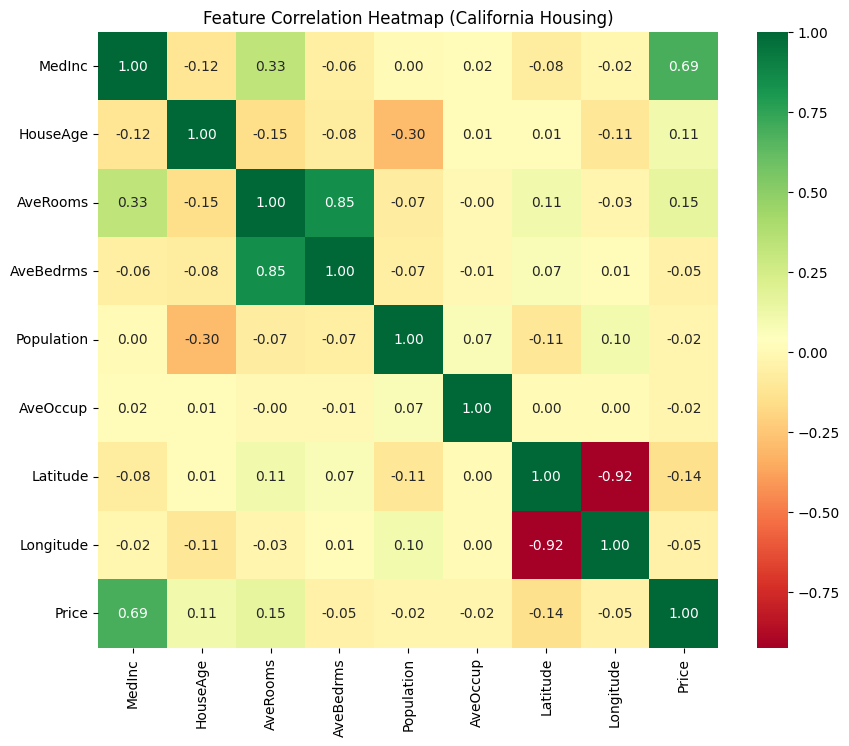

In [5]:


# Correlation Heatmap to see how features like 'AveRooms' affect 'Price'
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Feature Correlation Heatmap (California Housing)")
plt.show()

# 3. PREPROCESSING
# Features: AveRooms (Size), AveBedrms (Bedrooms), Lat/Long (Location)
X = df.drop('Price', axis=1)
y = df['Price']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (Standardizing features for better model performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)





In [6]:
# 4. MODEL TRAINING (Gradient Boosting)
print("\nTraining the Gradient Boosting model... please wait.")
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. EVALUATION
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Model Performance ---")
print(f"Mean Absolute Error: {mae:.4f} (units of $100k)")
print(f"RMSE: {rmse:.4f}")
print(f"R-Squared Score: {r2:.4f}")


Training the Gradient Boosting model... please wait.

--- Model Performance ---
Mean Absolute Error: 0.3349 (units of $100k)
RMSE: 0.4977
R-Squared Score: 0.8110


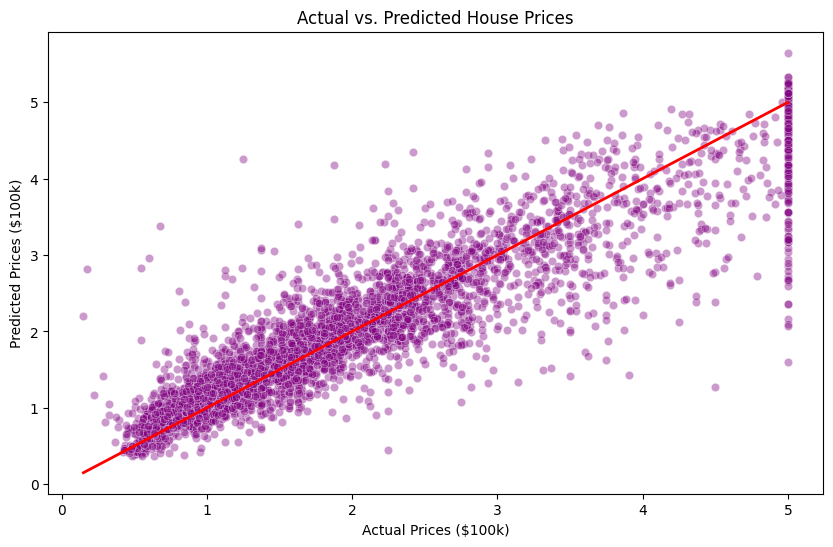

Model Saved Successfully!


In [7]:
# 6. VISUALIZATION: ACTUAL VS PREDICTED
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel("Actual Prices ($100k)")
plt.ylabel("Predicted Prices ($100k)")
plt.title("Actual vs. Predicted House Prices")
plt.show()
joblib.dump(model, 'house_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model Saved Successfully!")